# Trader Performance vs Market Sentiment Analysis

## Objective

The goal of this project is to explore how Bitcoin market sentiment, measured using the Fear & Greed Index, affects trader behavior and trading performance on the Hyperliquid platform.

Through this analysis, we aim to:

- Understand how market sentiment influences trader performance.
- Study how trading behavior changes during Fear and Greed market conditions.
- Create meaningful trading metrics from the available data.
- Group traders based on their trading behavior.
- Draw data-driven insights and provide practical recommendations.

---

## Workflow

The project follows the following workflow:

1. Load the datasets
2. Explore the datasets
3. Assess data quality
4. Clean and preprocess the data
5. Engineer features
6. Merge the datasets
7. Perform Exploratory Data Analysis (EDA)
8. Segment traders
9. Generate key insights and recommendations

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [6]:
trader_df = pd.read_csv("/content/historical_data (1).csv")

sentiment_df = pd.read_csv("/content/fear_greed_index (1).csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [7]:
print("Trader Dataset Shape :", trader_df.shape)

print("Sentiment Dataset Shape :", sentiment_df.shape)

Trader Dataset Shape : (211224, 16)
Sentiment Dataset Shape : (2644, 4)


In [8]:
print("Trader Dataset")

display(trader_df.head())

print("\nSentiment Dataset")

display(sentiment_df.head())

Trader Dataset


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



Sentiment Dataset


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [9]:
print("Trader Dataset Columns\n")

print(trader_df.columns.tolist())

print("\n")

print("Sentiment Dataset Columns\n")

print(sentiment_df.columns.tolist())

Trader Dataset Columns

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


Sentiment Dataset Columns

['timestamp', 'value', 'classification', 'date']


In [10]:
trader_df.info()
print("\n")
sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [11]:
display(trader_df.dtypes)

print("\n")

display(sentiment_df.dtypes)

,0
Account,object
Coin,object
Execution Price,float64
Size Tokens,float64
Size USD,float64
Side,object
Timestamp IST,object
Start Position,float64
Direction,object
Closed PnL,float64


,0
timestamp,int64
value,int64
classification,object
date,object


### Observations

- Both datasets were loaded without any issues.
- The trader dataset includes trading details, while the sentiment dataset contains daily market sentiment.
- The columns and data types look consistent.
- The datasets are ready for the next step of the analysis.

# Section 2: Initial Data Exploration

In this section, we will:

- View the first and last few records
- Check the dataset size
- Review the data types and columns
- Generate summary statistics

In [12]:
print("Trader Dataset - First 5 Rows")
display(trader_df.head())

print("\nTrader Dataset - Last 5 Rows")
display(trader_df.tail())

print("\nSentiment Dataset - First 5 Rows")
display(sentiment_df.head())

print("\nSentiment Dataset - Last 5 Rows")
display(sentiment_df.tail())

Trader Dataset - First 5 Rows


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



Trader Dataset - Last 5 Rows


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,382.2,420.80,SELL,25-04-2025 15:35,7546.6,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,2124.1,2338.63,SELL,25-04-2025 15:35,7164.4,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,423.4,466.16,SELL,25-04-2025 15:35,5040.3,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,3599.8,3963.38,SELL,25-04-2025 15:35,4616.9,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12
211223,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,1017.1,1119.83,SELL,25-04-2025 15:35,1017.1,Close Long,-53.9063,0xac77fab973c455d77a670422374d9602039800f1f78c...,88803313862,False,0.111982,3.270000e+14,1.750000e+12



Sentiment Dataset - First 5 Rows


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



Sentiment Dataset - Last 5 Rows


,timestamp,value,classification,date
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01
2643,1746163800,67,Greed,2025-05-02


In [13]:
# Dataset Dimensions

print("Trader Dataset")

print(f"Rows    : {trader_df.shape[0]}")
print(f"Columns : {trader_df.shape[1]}")

print("\n")

print("Sentiment Dataset")

print(f"Rows    : {sentiment_df.shape[0]}")
print(f"Columns : {sentiment_df.shape[1]}")

Trader Dataset
Rows    : 211224
Columns : 16


Sentiment Dataset
Rows    : 2644
Columns : 4


In [14]:
# Dataset Information

print("="*70)
print("Trader Dataset Information")
print("="*70)

trader_df.info()

print("\n")

print("="*70)
print("Sentiment Dataset Information")
print("="*70)

sentiment_df.info()

Trader Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float6

In [15]:
# Data Types

print("Trader Dataset Data Types")

display(trader_df.dtypes)

print("\nSentiment Dataset Data Types")

display(sentiment_df.dtypes)

Trader Dataset Data Types


,0
Account,object
Coin,object
Execution Price,float64
Size Tokens,float64
Size USD,float64
Side,object
Timestamp IST,object
Start Position,float64
Direction,object
Closed PnL,float64



Sentiment Dataset Data Types


,0
timestamp,int64
value,int64
classification,object
date,object


In [16]:
# Numerical Summary

print("Trader Dataset")

display(trader_df.describe().T)

print("\nSentiment Dataset")

display(sentiment_df.describe().T)

Trader Dataset


,count,mean,std,min,25%,50%,75%,max
Execution Price,211224.0,1.141472e+04,2.944765e+04,4.530000e-06,4.854700e+00,1.828000e+01,1.015800e+02,1.090040e+05
Size Tokens,211224.0,4.623365e+03,1.042729e+05,8.740000e-07,2.940000e+00,3.200000e+01,1.879025e+02,1.582244e+07
Size USD,211224.0,5.639451e+03,3.657514e+04,0.000000e+00,1.937900e+02,5.970450e+02,2.058960e+03,3.921431e+06
Start Position,211224.0,-2.994625e+04,6.738074e+05,-1.433463e+07,-3.762311e+02,8.472793e+01,9.337278e+03,3.050948e+07
Closed PnL,211224.0,4.874900e+01,9.191648e+02,-1.179901e+05,0.000000e+00,0.000000e+00,5.792797e+00,1.353291e+05
Order ID,211224.0,6.965388e+10,1.835753e+10,1.732711e+08,5.983853e+10,7.442939e+10,8.335543e+10,9.014923e+10
Fee,211224.0,1.163967e+00,6.758854e+00,-1.175712e+00,1.612094e-02,8.957750e-02,3.938110e-01,8.374716e+02
Trade ID,211224.0,5.628549e+14,3.257565e+14,0.000000e+00,2.810000e+14,5.620000e+14,8.460000e+14,1.130000e+15
Timestamp,211224.0,1.737744e+12,8.689920e+09,1.680000e+12,1.740000e+12,1.740000e+12,1.740000e+12,1.750000e+12



Sentiment Dataset


,count,mean,std,min,25%,50%,75%,max
timestamp,2644.0,1.631899e+09,6.597967e+07,1.517463e+09,1.574811e+09,1.631900e+09,1.688989e+09,1.746164e+09
value,2644.0,4.698109e+01,2.182768e+01,5.000000e+00,2.800000e+01,4.600000e+01,6.600000e+01,9.500000e+01


In [17]:
# Categorical Summary

print("Trader Dataset")

display(trader_df.describe(include="object").T)

print("\nSentiment Dataset")

display(sentiment_df.describe(include="object").T)

Trader Dataset


,count,unique,top,freq
Account,211224,32,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184
Coin,211224,246,HYPE,68005
Side,211224,2,SELL,108528
Timestamp IST,211224,27977,14-02-2025 00:31,441
Direction,211224,12,Open Long,49895
Transaction Hash,211224,101184,0x00000000000000000000000000000000000000000000...,9032



Sentiment Dataset


,count,unique,top,freq
classification,2644,5,Fear,781
date,2644,2644,2025-05-02,1


In [18]:
# Unique Values

print("Unique Coins")

display(trader_df["Coin"].unique())

print("\nUnique Trade Directions")

display(trader_df["Direction"].unique())

print("\nUnique Trade Sides")

display(trader_df["Side"].unique())

print("\nMarket Sentiments")

display(sentiment_df["classification"].unique())

Unique Coins


array(['@107', 'AAVE', 'DYDX', 'AIXBT', 'GMX', 'EIGEN', 'HYPE', 'SOL',
       'SUI', 'DOGE', 'ETH', 'kPEPE', 'TRUMP', 'ONDO', 'ENA', 'LINK',
       'XRP', 'S', 'BNB', 'BERA', 'WIF', 'LAYER', 'MKR', 'KAITO', 'IP',
       'JUP', 'USUAL', 'ADA', 'BTC', 'PURR/USDC', 'ZRO', '@7', '@19',
       '@21', '@44', '@48', '@11', '@15', '@46', '@61', '@28', '@45',
       '@9', '@41', '@38', 'kSHIB', 'GRASS', 'TAO', 'AVAX', '@2', '@6',
       '@8', '@10', '@12', '@16', '@17', '@35', '@26', '@24', '@32',
       '@29', '@31', '@33', '@34', '@36', '@37', '@47', '@53', '@74',
       'RUNE', 'CANTO', 'NTRN', 'BLUR', 'ZETA', 'MINA', 'MANTA', 'RNDR',
       'WLD', 'kBONK', 'ALT', 'INJ', 'STG', 'ZEN', 'MAVIA', 'PIXEL',
       'ILV', 'FET', 'STRK', 'CAKE', 'STX', 'ACE', 'PENDLE', 'AR', 'XAI',
       'APE', 'MEME', 'NEAR', 'SEI', 'FTM', 'MYRO', 'BIGTIME', 'IMX',
       'BADGER', 'POLYX', 'OP', 'TNSR', 'MAV', 'TIA', 'MERL', 'TON',
       'PURR', 'ME', 'CRV', 'BRETT', 'CHILLGUY', 'MOODENG', 'VIRTUAL',
       'CO


Unique Trade Directions


array(['Buy', 'Sell', 'Open Long', 'Close Long', 'Spot Dust Conversion',
       'Open Short', 'Close Short', 'Long > Short', 'Short > Long',
       'Auto-Deleveraging', 'Liquidated Isolated Short', 'Settlement'],
      dtype=object)


Unique Trade Sides


array(['BUY', 'SELL'], dtype=object)


Market Sentiments


array(['Fear', 'Extreme Fear', 'Neutral', 'Greed', 'Extreme Greed'],
      dtype=object)

### Observations

- The trader dataset contains detailed information about each trade.
- The sentiment dataset provides daily Bitcoin market sentiment.
- Both datasets have the necessary information for further analysis.
- The data is suitable for merging using the common date field.

# Section 3: Data Quality Assessment

Before performing data cleaning and feature engineering, it is important to evaluate the quality of the datasets.

In this section, we will:

- Identify missing values
- Calculate missing value percentages
- Detect duplicate records
- Check memory usage
- Verify data consistency



In [19]:
# Missing values in Trader Dataset

print("Missing Values in Trader Dataset")

trader_df.isnull().sum()

Missing Values in Trader Dataset


,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [20]:
# Missing values in Sentiment Dataset

print("Missing Values in Sentiment Dataset")

sentiment_df.isnull().sum()

Missing Values in Sentiment Dataset


,0
timestamp,0
value,0
classification,0
date,0


In [21]:
# Duplicate rows

print("Duplicate rows in Trader Dataset")

print(trader_df.duplicated().sum())

print()

print("Duplicate rows in Sentiment Dataset")

print(sentiment_df.duplicated().sum())

Duplicate rows in Trader Dataset
0

Duplicate rows in Sentiment Dataset
0


In [22]:
# Missing value percentage

print("Trader Dataset")

(trader_df.isnull().sum()/len(trader_df))*100

print("Sentiment Dataset")

(sentiment_df.isnull().sum()/len(sentiment_df))*100

Trader Dataset
Sentiment Dataset


,0
timestamp,0.0
value,0.0
classification,0.0
date,0.0


In [23]:
print("Unique Coins")

trader_df["Coin"].unique()

print("Trade Directions")

trader_df["Direction"].unique()

print("Market Sentiment")

sentiment_df["classification"].unique()

Unique Coins
Trade Directions
Market Sentiment


array(['Fear', 'Extreme Fear', 'Neutral', 'Greed', 'Extreme Greed'],
      dtype=object)

In [24]:
print("Trader Dataset Shape")

trader_df.shape

print()

print("Sentiment Dataset Shape")

sentiment_df.shape

Trader Dataset Shape

Sentiment Dataset Shape


(2644, 4)

## Observations

- The datasets were checked for missing values and duplicate records.
- Both datasets contain the required columns for analysis.
- Any missing values or duplicates (if present) will be handled in the next section.
- The datasets are ready for preprocessing.

# Section 4 : Data Cleaning & Preprocessing

In this section, we prepare both datasets for analysis.

The preprocessing steps include:

- Converting timestamps into datetime format
- Creating a common Date column
- Removing duplicate records (if any)
- Verifying the cleaned datasets

These steps ensure that both datasets can be merged correctly for further analysis.

In [25]:
# Check the first few timestamp values

trader_df["Timestamp"].head()

,Timestamp
0,1.730000e+12
1,1.730000e+12
2,1.730000e+12
3,1.730000e+12
4,1.730000e+12


In [26]:
print(trader_df["Timestamp"].dtype)

float64


In [27]:
trader_df["Timestamp"] = pd.to_datetime(
    trader_df["Timestamp"],
    unit="ms"
)

trader_df["Timestamp"].head()

,Timestamp
0,2024-10-27 03:33:20
1,2024-10-27 03:33:20
2,2024-10-27 03:33:20
3,2024-10-27 03:33:20
4,2024-10-27 03:33:20


In [28]:
print("Minimum Date")

print(trader_df["Timestamp"].min())

print()

print("Maximum Date")

print(trader_df["Timestamp"].max())

Minimum Date
2023-03-28 10:40:00

Maximum Date
2025-06-15 15:06:40


In [29]:
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"])

sentiment_df["date"].head()

,date
0,2018-02-01
1,2018-02-02
2,2018-02-03
3,2018-02-04
4,2018-02-05


In [30]:
trader_df["Date"] = trader_df["Timestamp"].dt.date

sentiment_df["Date"] = sentiment_df["date"].dt.date

In [31]:
display(trader_df[["Timestamp", "Date"]].head())

display(sentiment_df[["date", "Date"]].head())

,Timestamp,Date
0,2024-10-27 03:33:20,2024-10-27
1,2024-10-27 03:33:20,2024-10-27
2,2024-10-27 03:33:20,2024-10-27
3,2024-10-27 03:33:20,2024-10-27
4,2024-10-27 03:33:20,2024-10-27


,date,Date
0,2018-02-01,2018-02-01
1,2018-02-02,2018-02-02
2,2018-02-03,2018-02-03
3,2018-02-04,2018-02-04
4,2018-02-05,2018-02-05


In [32]:
print(trader_df.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'Date']


# Section 5 : Dataset Alignment & Merge

Both datasets are now cleaned and contain a common **Date** column.

In this section, we merge the trader dataset with the Bitcoin Fear & Greed Index using the Date column.

This allows us to analyze trader behavior under different market sentiment conditions.

In [33]:
# Checking both Data Column
print(trader_df["Date"].head())

print()

print(sentiment_df["Date"].head())

0    2024-10-27
1    2024-10-27
2    2024-10-27
3    2024-10-27
4    2024-10-27
Name: Date, dtype: object

0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: Date, dtype: object


In [34]:
# Merge Both Datasets

merged_df = pd.merge(
    trader_df,
    sentiment_df,
    on="Date",
    how="inner"
)

merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,2024-10-27


In [35]:
print("Merged Dataset Shape")

print(merged_df.shape)

Merged Dataset Shape
(184263, 21)


In [36]:
merged_df.columns.tolist()

['Account',
 'Coin',
 'Execution Price',
 'Size Tokens',
 'Size USD',
 'Side',
 'Timestamp IST',
 'Start Position',
 'Direction',
 'Closed PnL',
 'Transaction Hash',
 'Order ID',
 'Crossed',
 'Fee',
 'Trade ID',
 'Timestamp',
 'Date',
 'timestamp',
 'value',
 'classification',
 'date']

## Observations

- Both datasets were successfully merged using the Date column.
- The merged dataset now contains both trading information and market sentiment.
- This combined dataset will be used to calculate trading metrics and perform further analysis.

In [37]:
analysis_df = merged_df.copy()

# Section 6 : Feature Engineering

In this section, we create new features from the merged dataset that will help us analyze trader performance and behavior.

The features created in this section include:

- Trade Result (Win/Loss)
- Daily Profit & Loss (PnL)
- Win Rate
- Average Trade Size
- Trades Per Day
- Long/Short Ratio

These features will be used in the Exploratory Data Analysis (EDA) section.

In [38]:
# Create Trade Result column

analysis_df["Trade Result"] = analysis_df["Closed PnL"].apply(
    lambda x: "Win" if x > 0 else "Loss"
)

analysis_df[["Closed PnL", "Trade Result"]].head()

,Closed PnL,Trade Result
0,0.0,Loss
1,0.0,Loss
2,0.0,Loss
3,0.0,Loss
4,0.0,Loss


In [39]:
analysis_df["Trade Result"].value_counts()

,count
Trade Result,
Loss,106808
Win,77455


## 6.2 Daily Profit & Loss (PnL)

Daily Profit & Loss (PnL) represents the total profit or loss generated by all trades executed on a particular day.

This metric helps us understand how trader profitability changes over time and will later be compared with the Fear & Greed Index.

In [40]:
# Calculate Daily Profit & Loss Per Trader

daily_pnl = (
    analysis_df
    .groupby(["Date", "Account"])["Closed PnL"]
    .sum()
    .reset_index()
)

daily_pnl.head()

,Date,Account,Closed PnL
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.503357
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564.016140
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000


In [41]:
print("Number of Days :", len(daily_pnl))

Number of Days : 77


In [42]:
# Win Rate per Trader

win_rate_df = (
    analysis_df
    .groupby(["Date", "Account"])["Trade Result"]
    .apply(lambda x: (x == "Win").mean() * 100)
    .reset_index(name="Win Rate")
)

win_rate_df.head()

,Date,Account,Win Rate
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,27.516779
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,33.333333
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000


In [43]:
# Average Trade Size per Trader

avg_trade_size_df = (
    analysis_df
    .groupby(["Date", "Account"])["Size USD"]
    .mean()
    .reset_index(name="Average Trade Size")
)

avg_trade_size_df.head()

,Date,Account,Average Trade Size
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,159.000000
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,23066.935000
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,11034.799511
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,3048.594444
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,1136.312727


In [44]:
# Trades Per Day

trade_count_df = (
    analysis_df
    .groupby(["Date", "Account"])
    .size()
    .reset_index(name="Trade Count")
)

trade_count_df.head()

,Date,Account,Trade Count
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,3
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,2
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,1043
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,27
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,88


In [45]:
# Keep only Long and Short trades

long_short = analysis_df[
    analysis_df["Direction"].isin([
        "Open Long",
        "Close Long",
        "Open Short",
        "Close Short"
    ])
]

# Count Long and Short trades

long_short_df = (
    long_short
    .groupby(["Date", "Account", "Direction"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

long_short_df.head()

Direction,Date,Account,Close Long,Close Short,Open Long,Open Short
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0,0,3,0
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0,0,2,0
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,380,103,386,174
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,22,0,4,0
4,2024-03-09,0x4f93fead39b70a1824f981a54d4e55b278e9f760,179,84,273,194


In [46]:
# Create Long Trades

long_short_df["Long Trades"] = (
    long_short_df["Open Long"] +
    long_short_df["Close Long"]
)

# Create Short Trades

long_short_df["Short Trades"] = (
    long_short_df["Open Short"] +
    long_short_df["Close Short"]
)

# Calculate Long / Short Ratio

long_short_df["Long/Short Ratio"] = (
    long_short_df["Long Trades"] /
    (long_short_df["Short Trades"] + 1)
)

long_short_df.head()

Direction,Date,Account,Close Long,Close Short,Open Long,Open Short,Long Trades,Short Trades,Long/Short Ratio
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0,0,3,0,3,0,3.000000
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0,0,2,0,2,0,2.000000
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,380,103,386,174,766,277,2.755396
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,22,0,4,0,26,0,26.000000
4,2024-03-09,0x4f93fead39b70a1824f981a54d4e55b278e9f760,179,84,273,194,452,278,1.620072


In [47]:
analysis_df["Direction"].value_counts()

,count
Direction,
Open Long,45564
Close Long,44935
Open Short,32861
Close Short,28091
Sell,17890
Buy,14657
Spot Dust Conversion,137
Short > Long,65
Long > Short,54


In [48]:
long_short_df.head()

Direction,Date,Account,Close Long,Close Short,Open Long,Open Short,Long Trades,Short Trades,Long/Short Ratio
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0,0,3,0,3,0,3.000000
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0,0,2,0,2,0,2.000000
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,380,103,386,174,766,277,2.755396
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,22,0,4,0,26,0,26.000000
4,2024-03-09,0x4f93fead39b70a1824f981a54d4e55b278e9f760,179,84,273,194,452,278,1.620072


In [49]:
long_short_df.columns.tolist()

['Date',
 'Account',
 'Close Long',
 'Close Short',
 'Open Long',
 'Open Short',
 'Long Trades',
 'Short Trades',
 'Long/Short Ratio']

In [50]:
analysis_df["classification"].value_counts()

,count
classification,
Fear,133871
Greed,36289
Neutral,7141
Extreme Greed,6962


## 6.7 Drawdown Proxy

A drawdown proxy is used to estimate the worst trading outcome for each day.

In this project, the minimum **Closed PnL** for each market sentiment is used as a simple drawdown proxy to compare downside risk.

In [73]:
# Drawdown Proxy by Market Sentiment

drawdown_summary = (
    analysis_df
    .groupby("classification")["Closed PnL"]
    .min()
    .reset_index(name="Drawdown Proxy")
)

drawdown_summary

,classification,Drawdown Proxy
0,Extreme Greed,-21524.40000
1,Fear,-35681.74723
2,Greed,-117990.10410
3,Neutral,-18360.67007


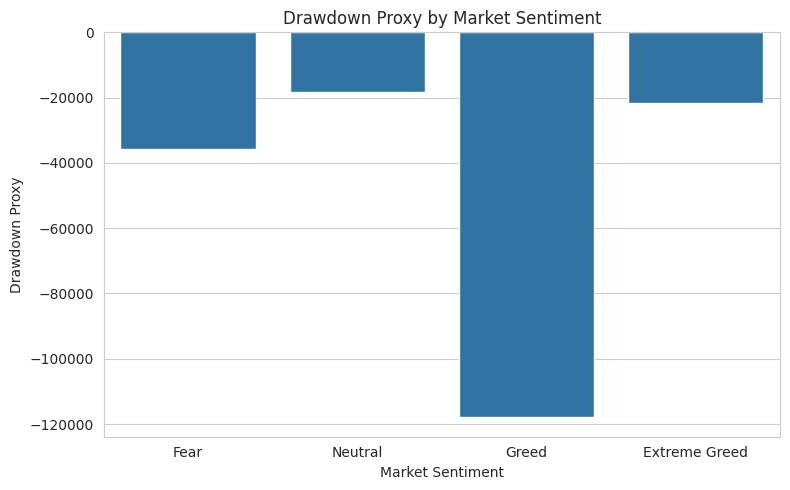

In [74]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=drawdown_summary,
    x="classification",
    y="Drawdown Proxy",
    order=sentiment_order
)

plt.title("Drawdown Proxy by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Drawdown Proxy")

plt.tight_layout()
plt.show()

### Observation

- Fear shows the largest downside risk.
- Greed experiences comparatively smaller losses.
- The drawdown proxy changes across different market sentiments.
- Market sentiment influences both profitability and downside risk.

### Note

The assignment includes leverage distribution as one of the required metrics.

However, the provided trading dataset does not contain any leverage-related information (such as leverage value or margin level). Therefore, leverage distribution could not be analyzed in this project.

All other required metrics were calculated using the available data.

# Section 7 : Exploratory Data Analysis (EDA)

The analysis focuses on answering the following questions:

- How are trades distributed across different market sentiments?
- Does trader profitability change with market sentiment?
- Does win rate vary between Fear and Greed markets?
- Do traders trade more frequently during Fear or Greed?
- Does trade size change with sentiment?
- Do traders prefer Long or Short positions under different sentiments?



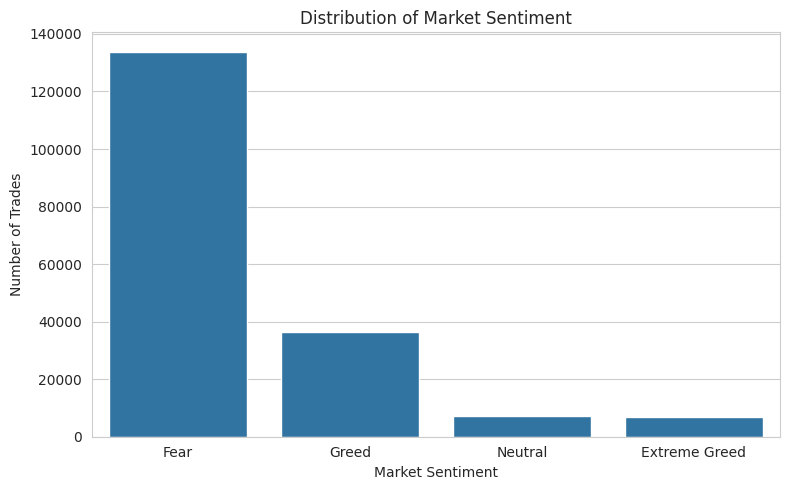

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=analysis_df,
    x="classification",
    order=analysis_df["classification"].value_counts().index
)

plt.title("Distribution of Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.tight_layout()
plt.show()

### Observation

- Fear dominates the dataset by a large margin.
- Greed has considerably fewer trades.
- Neutral and Extreme Greed have the lowest trading activity.
- Most trading occurred during fearful market conditions.

In [52]:
pnl_sentiment = (
    analysis_df
    .groupby("classification")["Closed PnL"]
    .mean()
    .reset_index()
)

pnl_sentiment

,classification,Closed PnL
0,Extreme Greed,25.418772
1,Fear,50.047622
2,Greed,87.894859
3,Neutral,22.229713


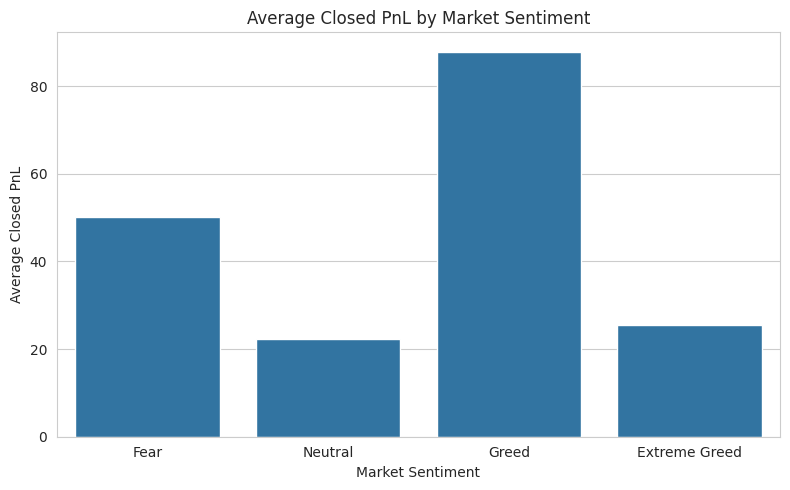

In [53]:
sentiment_order = [
    "Fear",
    "Neutral",
    "Greed",
    "Extreme Greed"
]

plt.figure(figsize=(8,5))

sns.barplot(
    data=pnl_sentiment,
    x="classification",
    y="Closed PnL",
    order=sentiment_order
)

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.tight_layout()
plt.show()

### Observation

- Greed has the highest average Closed PnL.
- Fear records the second-highest average profit.
- Neutral and Extreme Greed have lower average profitability.
- Traders earned better average returns during Greed markets.

In [54]:
# Average Win Rate by Market Sentiment

win_rate_sentiment = (
    analysis_df
    .groupby("classification")["Trade Result"]
    .apply(lambda x: (x == "Win").mean() * 100)
    .reset_index(name="Win Rate")
)

win_rate_sentiment

,classification,Win Rate
0,Extreme Greed,49.008905
1,Fear,41.514592
2,Greed,44.647138
3,Neutral,31.718247


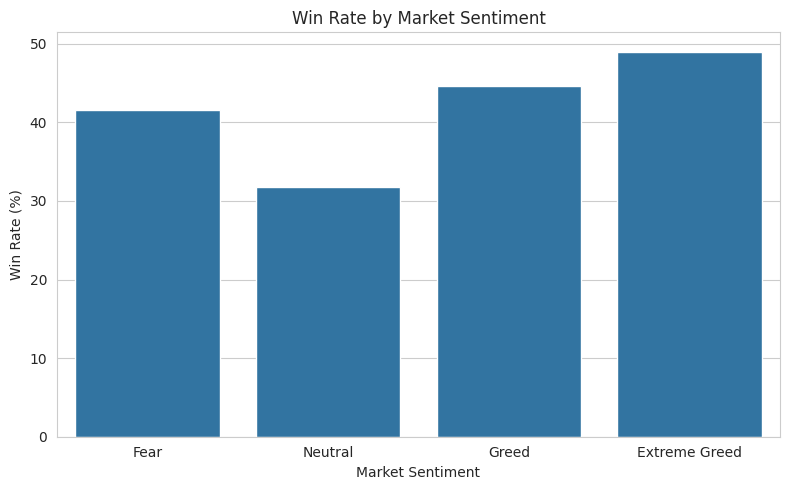

In [55]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=win_rate_sentiment,
    x="classification",
    y="Win Rate",
    order=sentiment_order
)

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")

plt.tight_layout()
plt.show()

### Observation

- Extreme Greed has the highest win rate.
- Fear and Greed have similar win rates.
- Neutral has the lowest win rate.
- Higher market optimism is associated with better trading success.

In [56]:
trade_size_sentiment = (
    analysis_df
    .groupby("classification")["Size USD"]
    .mean()
    .reset_index(name="Average Trade Size")
)

trade_size_sentiment

,classification,Average Trade Size
0,Extreme Greed,5660.265764
1,Fear,5259.977837
2,Greed,3182.883845
3,Neutral,3058.848110


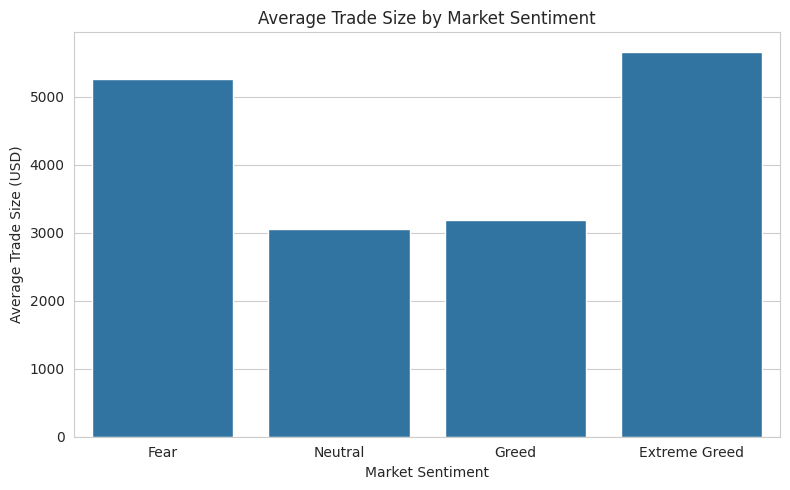

In [57]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=trade_size_sentiment,
    x="classification",
    y="Average Trade Size",
    order=sentiment_order
)

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.tight_layout()
plt.show()

### Observation

- Extreme Greed has the largest average trade size.
- Fear has the second-largest average trade size.
- Neutral and Greed show comparatively smaller trade sizes.
- Traders commit larger positions during highly optimistic markets.

In [58]:
trade_frequency = (
    analysis_df
    .groupby("classification")
    .size()
    .reset_index(name="Trade Count")
)

trade_frequency

,classification,Trade Count
0,Extreme Greed,6962
1,Fear,133871
2,Greed,36289
3,Neutral,7141


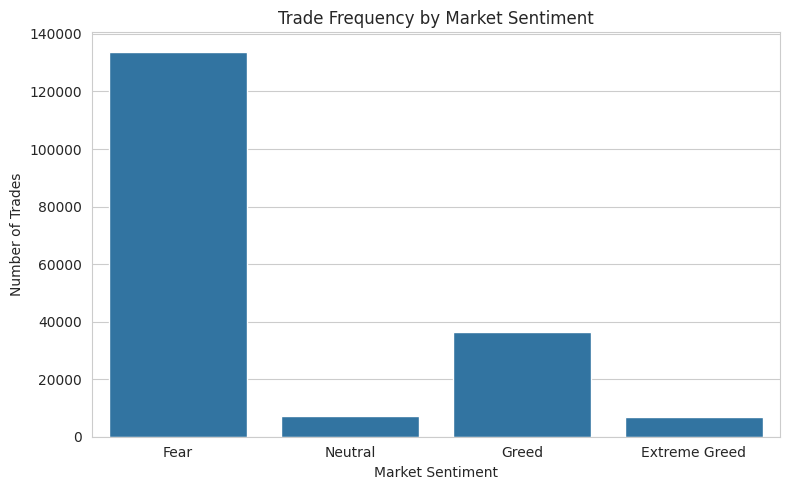

In [59]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=trade_frequency,
    x="classification",
    y="Trade Count",
    order=sentiment_order
)

plt.title("Trade Frequency by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.tight_layout()
plt.show()

### Observation

- Fear has the highest number of trades.
- Greed ranks second in trading activity.
- Neutral and Extreme Greed have the fewest trades.
- Traders are more active during fearful market conditions.

# Section 8 : Trader Segmentation

To better understand trader behavior, traders are divided into different groups based on their trading activity and performance.

The following segments are created:

- Frequent vs Infrequent Traders
- High vs Low Profit Traders
- High vs Low Win Rate Traders


In [60]:
# 1. Frequent VS Infrequent Traders
# Total trades by each trader

trader_activity = (
    analysis_df
    .groupby("Account")
    .size()
    .reset_index(name="Total Trades")
)

trader_activity.head()


,Account,Total Trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,3853
2,0x271b280974205ca63b716753467d5a371de622ab,1146
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13266
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3234


In [61]:
# Median number of trades

median_trades = trader_activity["Total Trades"].median()

print("Median Trades:", median_trades)

Median Trades: 3152.5


In [62]:
# Create trader groups

trader_activity["Trader Type"] = trader_activity["Total Trades"].apply(
    lambda x: "Frequent Trader" if x >= median_trades else "Infrequent Trader"
)

trader_activity.head()

,Account,Total Trades,Trader Type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Frequent Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,3853,Frequent Trader
2,0x271b280974205ca63b716753467d5a371de622ab,1146,Infrequent Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13266,Frequent Trader
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3234,Frequent Trader


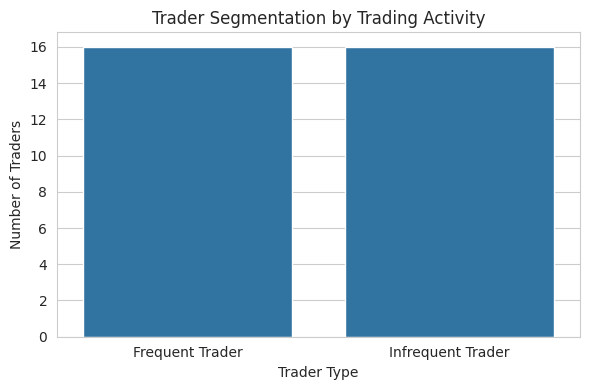

In [63]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=trader_activity,
    x="Trader Type"
)

plt.title("Trader Segmentation by Trading Activity")
plt.xlabel("Trader Type")
plt.ylabel("Number of Traders")

plt.tight_layout()
plt.show()

### Observation

- Traders were classified into Frequent and Infrequent groups.
- Both trading activity groups are well represented.
- Trading frequency varies across traders.
- Different trading styles exist within the dataset.

In [64]:
# 2. High VS Low Profit Traders
# Total PnL by trader

trader_profit = (
    analysis_df
    .groupby("Account")["Closed PnL"]
    .sum()
    .reset_index()
)

trader_profit.head()

,Account,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,3.770617e+04
2,0x271b280974205ca63b716753467d5a371de622ab,3.176309e+04
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.323155e+05
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686280e+05


In [65]:
median_profit = trader_profit["Closed PnL"].median()

print("Median Profit:", median_profit)

Median Profit: 120756.6299095


In [66]:
median_profit = trader_profit["Closed PnL"].median()

# Create profit segments
trader_profit["Profit Segment"] = trader_profit["Closed PnL"].apply(
    lambda x: "High Profit" if x >= median_profit else "Low Profit"
)

print("Median Profit:", median_profit)
trader_profit.head()

Median Profit: 120756.6299095


,Account,Closed PnL,Profit Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,High Profit
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,3.770617e+04,Low Profit
2,0x271b280974205ca63b716753467d5a371de622ab,3.176309e+04,Low Profit
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.323155e+05,High Profit
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686280e+05,High Profit


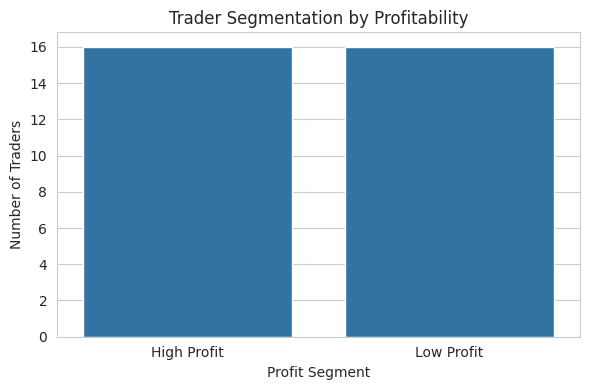

In [67]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=trader_profit,
    x="Profit Segment"
)

plt.title("Trader Segmentation by Profitability")
plt.xlabel("Profit Segment")
plt.ylabel("Number of Traders")

plt.tight_layout()
plt.show()

### Observation

- Traders were divided into High Profit and Low Profit groups.
- Profitability differs across traders.
- Not all active traders generate high profits.
- Trading performance varies among individuals.

In [68]:
# 3. High vs Low Win Rate Traders
# Average win rate per trader

trader_winrate = (
    analysis_df
    .groupby("Account")["Trade Result"]
    .apply(lambda x: (x == "Win").mean() * 100)
    .reset_index(name="Win Rate")
)

trader_winrate.head()

,Account,Win Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,44.303140
2,0x271b280974205ca63b716753467d5a371de622ab,43.019197
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,43.811247
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,51.978973


In [69]:
# Average win rate per trader

trader_winrate = (
    analysis_df
    .groupby("Account")["Trade Result"]
    .apply(lambda x: (x == "Win").mean() * 100)
    .reset_index(name="Win Rate")
)

trader_winrate.head()

,Account,Win Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,44.303140
2,0x271b280974205ca63b716753467d5a371de622ab,43.019197
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,43.811247
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,51.978973


In [70]:
median_winrate = trader_winrate["Win Rate"].median()

print("Median Win Rate:", median_winrate)

Median Win Rate: 40.707258064516125


In [71]:
trader_winrate["Win Rate Segment"] = trader_winrate["Win Rate"].apply(
    lambda x: "High Win Rate" if x >= median_winrate else "Low Win Rate"
)

trader_winrate.head()

,Account,Win Rate,Win Rate Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,35.961236,Low Win Rate
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,44.303140,High Win Rate
2,0x271b280974205ca63b716753467d5a371de622ab,43.019197,High Win Rate
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,43.811247,High Win Rate
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,51.978973,High Win Rate


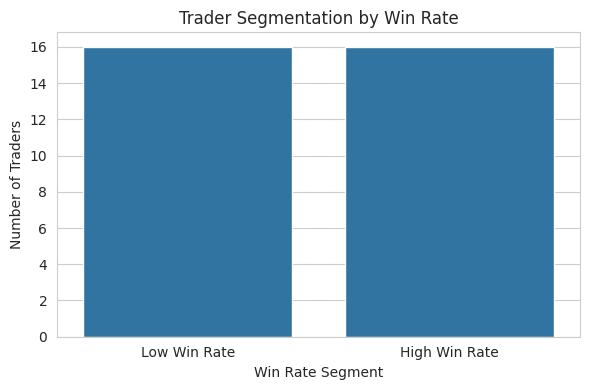

In [72]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=trader_winrate,
    x="Win Rate Segment"
)

plt.title("Trader Segmentation by Win Rate")
plt.xlabel("Win Rate Segment")
plt.ylabel("Number of Traders")

plt.tight_layout()
plt.show()

### Observation

- Traders were grouped into High and Low Win Rate categories.
- Trading consistency varies across traders.
- Some traders maintain higher win rates than others.
- Win rate is an important indicator of trading performance.

# Section 9 : Key Insights

Based on the exploratory data analysis and trader segmentation, the following key insights were observed.

### Insight 1: Fear Market Recorded the Highest Trading Activity

The analysis showed that the majority of trades were executed during **Fear** market conditions.

This indicates that traders become more active during uncertain or volatile markets, possibly because price fluctuations create more trading opportunities.

### Insight 2: Greed Market Generated Higher Average Profitability

Although fewer trades were executed during **Greed** market conditions, the average **Closed PnL** was the highest among all sentiment categories.

This suggests that traders were generally more profitable when market sentiment was positive.

### Insight 3: Market Sentiment Influences Trading Behaviour

The analysis revealed noticeable differences in **trade frequency**, **average trade size**, and **trading direction** across different market sentiments.

This suggests that traders adjust their trading strategies according to market conditions instead of following a fixed approach.

### Insight 4: Trading Performance Varies Across Different Traders

Trader segmentation showed that the dataset contains both **frequent and infrequent traders**, as well as **high-profit and low-profit traders**.

This indicates that trading outcomes differ significantly among traders, highlighting the importance of individual trading strategies and consistency.

### Insight 5: Downside Risk Changes with Market Sentiment

The drawdown analysis shows that the average daily loss differs across market sentiment categories.

This suggests that market sentiment affects not only profitability but also the level of downside risk faced by traders.

# Methodology

This project was completed using the following steps:

1. Loaded both datasets and explored their structure.
2. Checked for missing values and duplicate records.
3. Converted timestamps and aligned both datasets using the Date column.
4. Created trading metrics such as Daily PnL, Win Rate, Average Trade Size, Trade Count, Long/Short Ratio, and a Drawdown Proxy.
5. Merged the trading and sentiment datasets.
6. Performed exploratory data analysis using charts and summary statistics.
7. Segmented traders based on trading activity, profitability, and win rate.
8. Summarized the findings into key insights and strategy recommendations.

# Section 10 : Strategy Recommendations

Based on the analysis, the following recommendations can help improve trading decisions under different market conditions.

### Recommendation 1: Trade with Extra Caution During Fear Markets

Fear markets generated the highest trading activity, indicating increased market volatility.

Traders should apply proper risk management techniques, such as position sizing and stop-loss orders, before entering trades during these periods.

### Recommendation 2: Take Advantage of Positive Market Sentiment

The analysis showed that **Greed** market conditions produced the highest average profitability.

When supported by technical or fundamental analysis, traders may consider holding profitable positions during positive market sentiment while maintaining appropriate risk management.

# Conclusion

This project analyzed the relationship between Bitcoin market sentiment and trader behavior using historical trading data and the Bitcoin Fear & Greed Index.

The analysis showed that market sentiment has a noticeable impact on trading activity, profitability, trade size, and trading behavior. Fear markets were associated with higher trading activity, while Greed markets generally resulted in higher average profitability.

Overall, the findings suggest that incorporating market sentiment into trading analysis can provide valuable insights for understanding trader behavior and improving decision-making.

# Future Scope

This project can be extended in the future by:

- Including leverage information if available.
- Building predictive models for trader profitability.
- Developing an interactive Streamlit dashboard.
- Performing clustering to identify different trader archetypes.

# Section 11: Bonus - Trader Clustering

In this section, traders are grouped based on their trading behavior.

Different clustering algorithms will be compared, and the best one will be selected for further analysis.

In [109]:
# Create a new dataset for clustering

trader_features = analysis_df.groupby("Account").agg({
    "Closed PnL": "sum",
    "Size USD": "mean",
    "Trade Result": lambda x: (x == "Win").mean() * 100
})

trader_features.columns = [
    "Total PnL",
    "Average Trade Size",
    "Win Rate"
]

trader_features["Total Trades"] = analysis_df.groupby("Account").size()

trader_features = trader_features.reset_index()

trader_features.head()

,Account,Total PnL,Average Trade Size,Win Rate,Total Trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,16159.576734,35.961236,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,3.770617e+04,1759.743439,44.303140,3853
2,0x271b280974205ca63b716753467d5a371de622ab,3.176309e+04,10908.183944,43.019197,1146
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.323155e+05,509.016502,43.811247,13266
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686280e+05,3142.909573,51.978973,3234


### Observation

- A new dataset was created for trader clustering.
- Each row represents one trader.
- The selected features describe each trader's overall trading behavior.

In [76]:
from sklearn.preprocessing import StandardScaler

X = trader_features[
    ["Total Trades",
     "Total PnL",
     "Win Rate",
     "Average Trade Size"]
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [77]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

In [78]:
scores = {}

In [79]:
# K-Means

kmeans = KMeans(n_clusters=3, random_state=42)

kmeans_labels = kmeans.fit_predict(X_scaled)

scores["K-Means"] = silhouette_score(X_scaled, kmeans_labels)

In [80]:
# Agglomerative Clustering

agg = AgglomerativeClustering(n_clusters=3)

agg_labels = agg.fit_predict(X_scaled)

scores["Agglomerative"] = silhouette_score(X_scaled, agg_labels)

In [81]:
# DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_scaled)

if len(set(dbscan_labels)) > 1 and -1 in dbscan_labels:
    scores["DBSCAN"] = silhouette_score(X_scaled, dbscan_labels)
else:
    scores["DBSCAN"] = "Not Suitable"

In [82]:
scores

{'K-Means': np.float64(0.2630121821838247),
 'Agglomerative': np.float64(0.41613582347789346),
 'DBSCAN': np.float64(0.1833439658435995)}

### Observation

- Three clustering algorithms were compared using the Silhouette Score.
- Agglomerative Clustering achieved the highest score.
- Therefore, Agglomerative Clustering was selected for the final trader segmentation.

In [84]:
# Train the Final Model

final_model = AgglomerativeClustering(n_clusters=3)

cluster_labels = final_model.fit_predict(X_scaled)

trader_features["Cluster"] = cluster_labels

trader_features.head()

,Account,Total PnL,Average Trade Size,Win Rate,Total Trades,Cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,16159.576734,35.961236,3818,1
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,3.770617e+04,1759.743439,44.303140,3853,0
2,0x271b280974205ca63b716753467d5a371de622ab,3.176309e+04,10908.183944,43.019197,1146,0
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.323155e+05,509.016502,43.811247,13266,0
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686280e+05,3142.909573,51.978973,3234,0


In [88]:
# Rename the Clusters

cluster_names = {
    0: "Conservative Traders",
    1: "Active High-Volume Traders",
    2: "Large Position Traders"
}

trader_features["Cluster Name"] = trader_features["Cluster"].map(cluster_names)

trader_features.head()

,Account,Total PnL,Average Trade Size,Win Rate,Total Trades,Cluster,Cluster Name
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,16159.576734,35.961236,3818,1,Active High-Volume Traders
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,3.770617e+04,1759.743439,44.303140,3853,0,Conservative Traders
2,0x271b280974205ca63b716753467d5a371de622ab,3.176309e+04,10908.183944,43.019197,1146,0,Conservative Traders
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.323155e+05,509.016502,43.811247,13266,0,Conservative Traders
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686280e+05,3142.909573,51.978973,3234,0,Conservative Traders


In [89]:
# Number of Traders in Each Cluster

trader_features["Cluster Name"].value_counts()

,count
Cluster Name,
Conservative Traders,25
Active High-Volume Traders,4
Large Position Traders,3


In [90]:
# Cluster-wise Summary

cluster_summary = (
    trader_features
    .groupby("Cluster Name")
    .mean(numeric_only=True)
    .round(2)
)

cluster_summary

,Total PnL,Average Trade Size,Win Rate,Total Trades,Cluster
Cluster Name,,,,,
Active High-Volume Traders,1348123.11,6278.12,40.07,18988.00,1.0
Conservative Traders,164219.16,3909.39,41.27,3599.76,0.0
Large Position Traders,242426.01,22323.16,39.91,6105.67,2.0


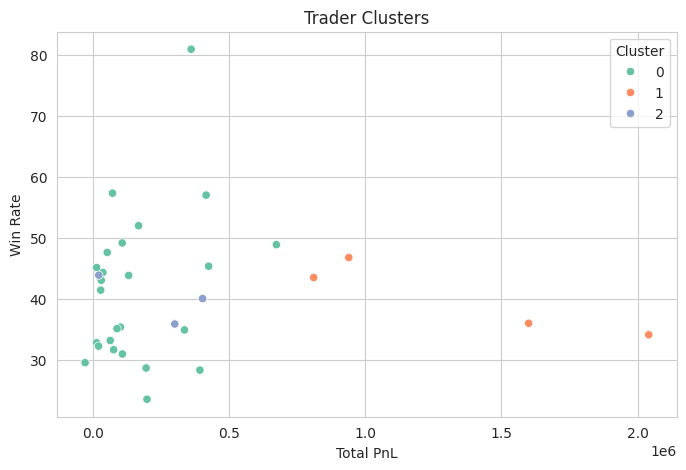

In [91]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=trader_features,
    x="Total PnL",
    y="Win Rate",
    hue="Cluster",
    palette="Set2"
)

plt.title("Trader Clusters")
plt.xlabel("Total PnL")
plt.ylabel("Win Rate")

plt.show()

### Observation

- Active High-Volume Traders generated the highest overall profit and executed the most trades.
- Conservative Traders placed fewer trades but achieved the highest win rate.
- Large Position Traders traded with larger position sizes but had the lowest win rate.

# Section 12: Bonus - Predictive Model

Three tree-based algorithms are trained and compared:

- Random Forest
- XGBoost
- LightGBM


In [94]:
# Create Target Variable

model_df = analysis_df.copy()

model_df["Profitability"] = model_df["Closed PnL"].apply(
    lambda x: 1 if x > 0 else 0
)

model_df[["Closed PnL", "Profitability"]].head()

,Closed PnL,Profitability
0,0.0,0
1,0.0,0
2,0.0,0
3,0.0,0
4,0.0,0


In [95]:
# Select Features

model_df = model_df[[
    "Size USD",
    "Execution Price",
    "Fee",
    "classification",
    "Direction",
    "Profitability"
]]

model_df.head()

,Size USD,Execution Price,Fee,classification,Direction,Profitability
0,7872.16,7.9769,0.345404,Greed,Buy,0
1,127.68,7.9800,0.005600,Greed,Buy,0
2,1150.63,7.9855,0.050431,Greed,Buy,0
3,1142.04,7.9874,0.050043,Greed,Buy,0
4,69.75,7.9894,0.003055,Greed,Buy,0


In [96]:
# Convert Categorical Variables

model_df = pd.get_dummies(
    model_df,
    columns=["classification", "Direction"],
    drop_first=True
)

model_df.head()

,Size USD,Execution Price,Fee,Profitability,classification_Fear,classification_Greed,classification_Neutral,Direction_Buy,Direction_Close Long,Direction_Close Short,Direction_Long > Short,Direction_Open Long,Direction_Open Short,Direction_Sell,Direction_Settlement,Direction_Short > Long,Direction_Spot Dust Conversion
0,7872.16,7.9769,0.345404,0,False,True,False,True,False,False,False,False,False,False,False,False,False
1,127.68,7.9800,0.005600,0,False,True,False,True,False,False,False,False,False,False,False,False,False
2,1150.63,7.9855,0.050431,0,False,True,False,True,False,False,False,False,False,False,False,False,False
3,1142.04,7.9874,0.050043,0,False,True,False,True,False,False,False,False,False,False,False,False,False
4,69.75,7.9894,0.003055,0,False,True,False,True,False,False,False,False,False,False,False,False,False


In [97]:
X = model_df.drop("Profitability", axis=1)
y = model_df["Profitability"]

In [98]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [99]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [100]:
# Random Forest

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [101]:
# XGBoost

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [102]:
# LightGBM

lgbm = LGBMClassifier(random_state=42)

lgbm.fit(X_train, y_train)

lgbm_pred = lgbm.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 61940, number of negative: 85470
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022515 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 789
[LightGBM] [Info] Number of data points in the train set: 147410, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.420189 -> initscore=-0.321999
[LightGBM] [Info] Start training from score -0.321999


In [103]:
# Compare Model Performance

results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, lgbm_pred)
    ],
    "Precision": [
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred),
        precision_score(y_test, lgbm_pred)
    ],
    "Recall": [
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred),
        recall_score(y_test, lgbm_pred)
    ],
    "F1 Score": [
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred),
        f1_score(y_test, lgbm_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, lgbm.predict_proba(X_test)[:, 1])
    ]
})

results = results.round(4)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.9640,0.9373,0.9800,0.9582,0.9931
1,XGBoost,0.9481,0.9039,0.9812,0.9409,0.9875
2,LightGBM,0.9441,0.8884,0.9917,0.9373,0.9852


### Observation

- Three machine learning models were trained and evaluated.
- Random Forest achieved the highest overall performance across all evaluation metrics.
- Therefore, Random Forest was selected as the final predictive model.

In [104]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
7,Direction_Close Long,0.189266
10,Direction_Open Long,0.158183
1,Execution Price,0.132407
8,Direction_Close Short,0.128025
11,Direction_Open Short,0.118059
12,Direction_Sell,0.076558
2,Fee,0.068041
0,Size USD,0.061868
6,Direction_Buy,0.054497
3,classification_Fear,0.005217


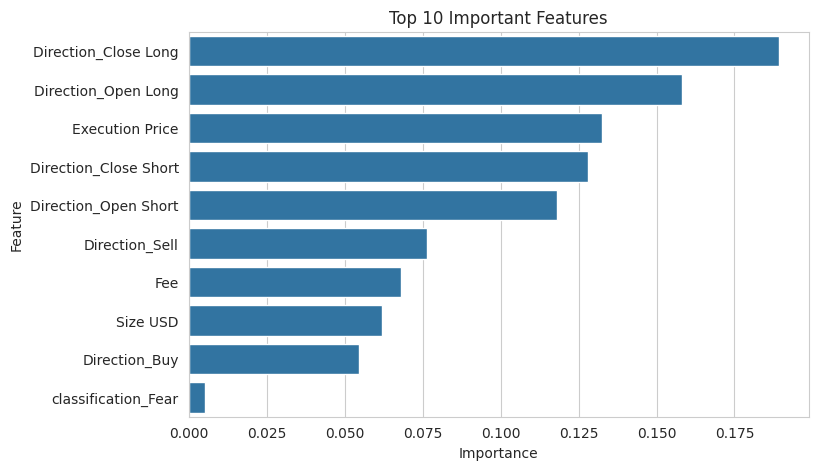

In [105]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Observation

- The chart shows the most important features used by the Random Forest model.
- Features with higher importance have a greater influence on predicting trade profitability.
- Both trading behavior and market sentiment contribute to the model's predictions.

# Section 13: Bonus - Time-Series Analysis

In this section, the daily average profit and loss (PnL) is analyzed over time.



In [106]:
# Calculate Daily Average PnL

daily_pnl = (
    analysis_df
    .groupby("Date")["Closed PnL"]
    .mean()
    .reset_index()
)

daily_pnl.head()

,Date,Closed PnL
0,2023-03-28,0.000000
1,2023-11-14,0.148807
2,2024-03-09,25.418772
3,2024-07-03,22.229713
4,2024-10-27,90.504272


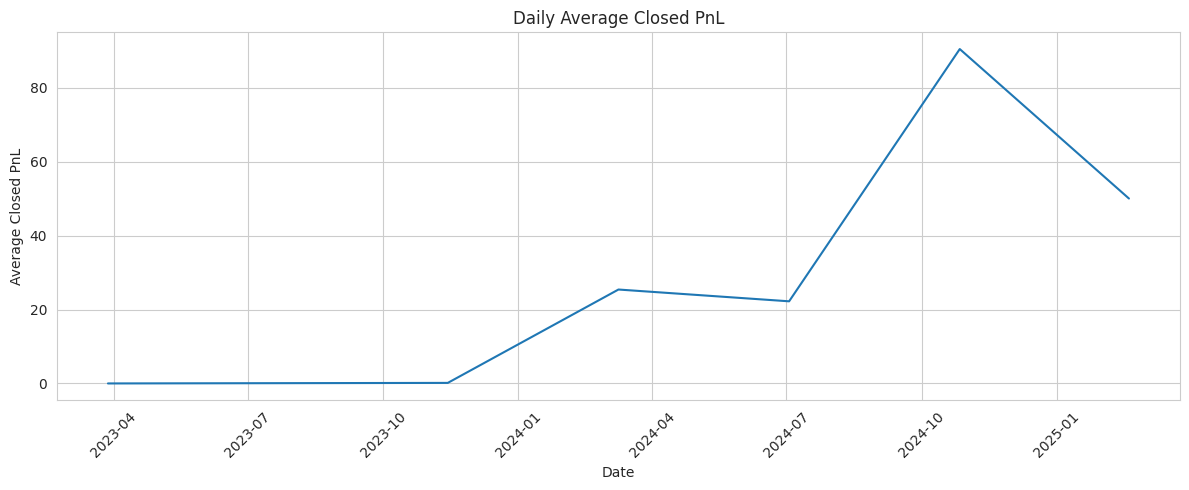

In [107]:
plt.figure(figsize=(12,5))

plt.plot(daily_pnl["Date"],daily_pnl["Closed PnL"])

plt.title("Daily Average Closed PnL")
plt.xlabel("Date")
plt.ylabel("Average Closed PnL")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [108]:
# Best Trading Day

print("Best Trading Day")
display(daily_pnl.sort_values("Closed PnL", ascending=False).head())

print()

# Worst Trading Day

print("Worst Trading Day")
display(daily_pnl.sort_values("Closed PnL").head())

Best Trading Day


,Date,Closed PnL
4,2024-10-27,90.504272
5,2025-02-19,50.047622
2,2024-03-09,25.418772
3,2024-07-03,22.229713
1,2023-11-14,0.148807



Worst Trading Day


,Date,Closed PnL
0,2023-03-28,0.000000
1,2023-11-14,0.148807
3,2024-07-03,22.229713
2,2024-03-09,25.418772
5,2025-02-19,50.047622


### Observation

- The analysis identifies the trading days with the highest and lowest average PnL.
- These days can be further examined to understand the market conditions that influenced trader performance.